# ICT Liquidity Debunk — Taker Buy % sur BTCUSDT

On entend souvent parler de "liquidité" dans le monde ICT (Inner Circle Trader). L'idée : les market makers chassent la liquidité au-dessus des highs et en-dessous des lows.

Dans ce notebook, on regarde une métrique concrète : le **% de taker buyers** (taker buy volume / volume total) sur Binance BTCUSDT.

- **Daily** : c'est plat, ~50%, rien à voir
- **M1** : chaos total entre 0% et 100%
- **Distribution** : le daily cache la réalité du M1

In [13]:
import requests
import pandas as pd
import numpy as np
import os
import time

from bokeh.plotting import figure, show
from bokeh.io import output_notebook, curdoc
from bokeh.layouts import gridplot, row
from bokeh.models import BoxAnnotation, Span, Label

output_notebook()
curdoc().theme = "dark_minimal"

# ── Constantes ──
SYMBOL = "ETHUSDT"
START = "2025-01-01"
END = "2026-01-01"
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

Loading BokehJS ...

In [14]:
def fetch_binance_klines_full(symbol, interval, start_ts, end_ts, cache_path=None):
    """
    Pagination Binance REST API (max 1000 par batch).
    Garde : open_time, open, high, low, close, volume, taker_buy_base.
    Cache en parquet si cache_path fourni.
    """
    if cache_path and os.path.exists(cache_path):
        print(f"Cache hit : {cache_path}")
        return pd.read_parquet(cache_path)

    url = "https://api.binance.com/api/v3/klines"
    all_rows = []
    current_start = start_ts

    while current_start < end_ts:
        params = {
            "symbol": symbol,
            "interval": interval,
            "startTime": current_start,
            "endTime": end_ts,
            "limit": 1000,
        }
        resp = requests.get(url, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not data:
            break

        all_rows.extend(data)
        # Avancer au-delà du dernier close_time
        current_start = data[-1][6] + 1
        print(f"  {interval} — {len(all_rows)} lignes fetched...", end="\r")

        if len(data) < 1000:
            break
        time.sleep(0.1)  # rate limit

    print(f"  {interval} — {len(all_rows)} lignes total.        ")

    cols = [
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_volume", "trades",
        "taker_buy_base", "taker_buy_quote", "ignore",
    ]
    df = pd.DataFrame(all_rows, columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms")
    for c in ["open", "high", "low", "close", "volume", "taker_buy_base"]:
        df[c] = df[c].astype(float)
    df = df[["open_time", "open", "high", "low", "close", "volume", "taker_buy_base"]]
    df = df.set_index("open_time").sort_index()

    if cache_path:
        df.to_parquet(cache_path)
        print(f"  Saved → {cache_path}")

    return df

In [15]:
# ── Timestamps ──
start_ts = int(pd.Timestamp(START).timestamp() * 1000)
end_ts = int(pd.Timestamp(END).timestamp() * 1000)

# ── Fetch M1 ──
print("Fetching M1...")
df_m1 = fetch_binance_klines_full(
    SYMBOL, "1m", start_ts, end_ts,
    cache_path=os.path.join(DATA_DIR, f"{SYMBOL}_1m.parquet"),
)


df_m1.head()

Fetching M1...
Cache hit : ./data/ETHUSDT_1m.parquet


,open,high,low,close,volume,taker_buy_base
open_time,,,,,,
2025-01-01 00:00:00,3337.78,3337.99,3335.84,3337.99,171.7281,66.7579
2025-01-01 00:01:00,3337.99,3338.86,3337.42,3338.86,69.0122,31.0429
2025-01-01 00:02:00,3338.86,3342.32,3338.86,3342.32,104.9957,79.9568
2025-01-01 00:03:00,3342.32,3342.44,3338.96,3339.98,183.7958,30.7626
2025-01-01 00:04:00,3339.98,3343.02,3339.98,3340.26,177.9110,126.0131


In [16]:

# ── pct_buy_takers M1 ──
df_m1["pct_buy_takers"] = df_m1["taker_buy_base"] / df_m1["volume"] * 100

# ── Daily : resample depuis M1 ──
df_daily = df_m1[["volume", "taker_buy_base", "close"]].resample("1D").agg({
    "volume": "sum",
    "taker_buy_base": "sum",
    "close": "last",
})
df_daily = df_daily[df_daily["volume"] > 0].copy()
df_daily["pct_buy_takers"] = df_daily["taker_buy_base"] / df_daily["volume"] * 100

print(f"\nM1 : {len(df_m1):,} lignes")
print(f"Daily : {len(df_daily)} lignes")
print(f"\nDaily pct_buy_takers — mean: {df_daily['pct_buy_takers'].mean():.2f}%, std: {df_daily['pct_buy_takers'].std():.2f}%")
print(f"M1 pct_buy_takers    — mean: {df_m1['pct_buy_takers'].mean():.2f}%, std: {df_m1['pct_buy_takers'].std():.2f}%")


M1 : 525,601 lignes
Daily : 366 lignes

Daily pct_buy_takers — mean: 49.31%, std: 2.68%
M1 pct_buy_takers    — mean: 49.30%, std: 20.67%


---

# Makers & Takers : le carnet d'ordres expliqué

Avant de plonger dans les données, il faut comprendre **qui crée** la liquidité et **qui la consomme**.  
Cliquez sur **Suivant ▶** pour naviguer dans les étapes.


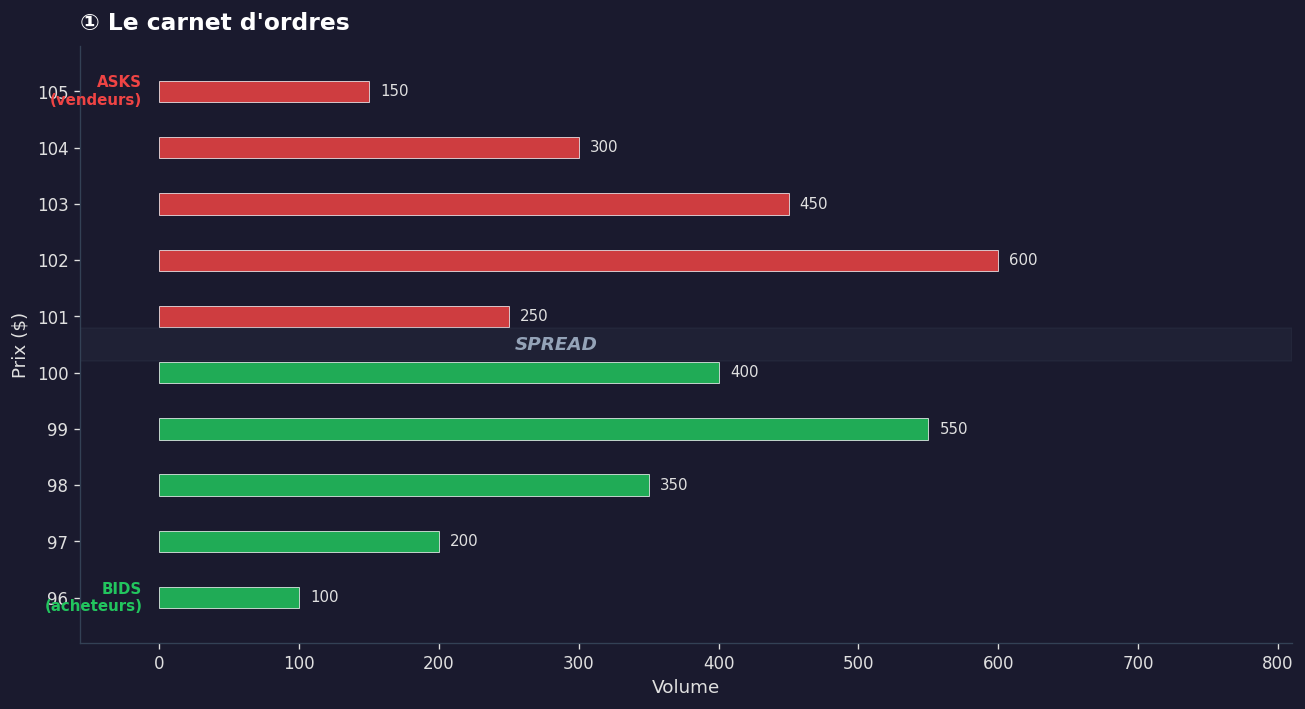

In [17]:
import matplotlib.pyplot as plt
import io, base64, json
from IPython.display import display, HTML

plt.ioff()

# ── Couleurs ──
BG      = "#1a1a2e"
ASK_C   = "#ef4444"
BID_C   = "#22c55e"
HI_C    = "#facc15"
HI_E    = "#f59e0b"
TXT_C   = "#e0e0e0"
BAR_H   = 0.38

# ── Scénarios ──
STEPS = [
    dict(
        title="① Le carnet d'ordres",
        badge=None,
        desc=(
            "Les <b>ASKS</b> (vendeurs) sont empilés en haut, "
            "les <b>BIDS</b> (acheteurs) en bas.<br>"
            "Chaque barre = volume en attente à ce prix. "
            "L'écart au milieu = le <b>spread</b>."
        ),
        asks=[(105,150),(104,300),(103,450),(102,600),(101,250)],
        bids=[(100,400),(99,550),(98,350),(97,200),(96,100)],
        ga=[], gb=[], hi=[],
    ),
    dict(
        title="② Limit Buy à 99.50 → MAKER",
        badge=("MAKER — ajoute de la liquidité", BID_C),
        desc=(
            "Un trader poste un <b>ordre limite</b> d'achat à 99.50.<br>"
            "Son ordre rejoint le carnet et <b>attend</b> d'être exécuté.<br>"
            "➜ Il est <span style='color:#22c55e;font-weight:bold'>MAKER</span> "
            "— il <b>ajoute</b> de la liquidité."
        ),
        asks=[(105,150),(104,300),(103,450),(102,600),(101,250)],
        bids=[(100,400),(99.5,180),(99,550),(98,350),(97,200),(96,100)],
        ga=[], gb=[], hi=[99.5],
    ),
    dict(
        title="③ Market Buy 800 unités → TAKER BUY",
        badge=("TAKER BUY — consomme les asks ↑", ASK_C),
        desc=(
            "Un trader achète <b>800 unités au marché</b>.<br>"
            "Son ordre <b>consomme</b> les asks du best ask vers le haut :<br>"
            "<code>250 @ 101</code> + <code>550 @ 102</code> = 800 mangées.<br>"
            "➜ Il est <span style='color:#ef4444;font-weight:bold'>TAKER BUY</span> "
            "— il <b>retire</b> de la liquidité."
        ),
        asks=[(105,150),(104,300),(103,450),(102,50)],
        bids=[(100,400),(99.5,180),(99,550),(98,350),(97,200),(96,100)],
        ga=[(101,250),(102,600)], gb=[], hi=[],
    ),
    dict(
        title="④ Market Sell 500 unités → TAKER SELL",
        badge=("TAKER SELL — consomme les bids ↓", ASK_C),
        desc=(
            "Un trader vend <b>500 unités au marché</b>.<br>"
            "Son ordre <b>consomme</b> les bids du best bid vers le bas :<br>"
            "<code>400 @ 100</code> + <code>100 @ 99.50</code> = 500 mangées.<br>"
            "➜ Il est <span style='color:#ef4444;font-weight:bold'>TAKER SELL</span> "
            "— il <b>retire</b> de la liquidité."
        ),
        asks=[(105,150),(104,300),(103,450),(102,50)],
        bids=[(99.5,80),(99,550),(98,350),(97,200),(96,100)],
        ga=[], gb=[(100,400),(99.5,180)], hi=[],
    ),
]

# ── Ranges globaux (axes stables) ──
_all_p, _all_q = set(), []
for _s in STEPS:
    for _p, _q in _s["asks"] + _s["bids"] + _s["ga"] + _s["gb"]:
        _all_p.add(_p); _all_q.append(_q)
Y_LO, Y_HI = min(_all_p) - 0.8, max(_all_p) + 0.8
X_HI = max(_all_q) * 1.35

def _fmt(p):
    return f"{p:.2f}" if p % 1 else f"{int(p)}"

# ── Rendu d'une frame → bytes PNG ──
def render(idx):
    s = STEPS[idx]
    fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
    ax.set_facecolor(BG)

    for p, q in s["ga"]:
        ax.barh(p, q, BAR_H, color=ASK_C, alpha=0.18,
                edgecolor=ASK_C, linewidth=1, linestyle="--")
        ax.text(q + 8, p, f"✗ {q}", va="center", color=ASK_C, alpha=0.35, fontsize=9)
    for p, q in s["gb"]:
        ax.barh(p, q, BAR_H, color=BID_C, alpha=0.18,
                edgecolor=BID_C, linewidth=1, linestyle="--")
        ax.text(q + 8, p, f"✗ {q}", va="center", color=BID_C, alpha=0.35, fontsize=9)

    for p, q in s["asks"]:
        if q <= 0: continue
        ax.barh(p, q, BAR_H, color=ASK_C, alpha=0.85, edgecolor="white", linewidth=0.5)
        ax.text(q + 8, p, str(q), va="center", color=TXT_C, fontsize=9)

    for p, q in s["bids"]:
        if q <= 0: continue
        is_hi = p in s["hi"]
        ax.barh(p, q, BAR_H, alpha=0.85,
                color=HI_C if is_hi else BID_C,
                edgecolor=HI_E if is_hi else "white",
                linewidth=2.5 if is_hi else 0.5)
        lbl = f"{q}  ◀ NOUVEAU" if is_hi else str(q)
        ax.text(q + 8, p, lbl, va="center", fontsize=9,
                color=HI_C if is_hi else TXT_C,
                fontweight="bold" if is_hi else "normal")

    ap = [p for p, q in s["asks"] if q > 0]
    bp = [p for p, q in s["bids"] if q > 0]
    if ap and bp:
        ba, bb = min(ap), max(bp)
        ax.axhspan(bb + BAR_H/2 + 0.02, ba - BAR_H/2 - 0.02, color="#475569", alpha=0.12)
        ax.text(X_HI * 0.35, (ba+bb)/2, "SPREAD", ha="center", va="center",
                color="#94a3b8", fontsize=11, fontweight="bold", style="italic")
    if ap:
        ax.text(-X_HI*0.015, max(ap), "ASKS\n(vendeurs)", ha="right",
                va="center", color=ASK_C, fontsize=9, fontweight="bold")
    if bp:
        ax.text(-X_HI*0.015, min(bp), "BIDS\n(acheteurs)", ha="right",
                va="center", color=BID_C, fontsize=9, fontweight="bold")

    prices = sorted({p for p,_ in s["asks"]+s["bids"]+s["ga"]+s["gb"]})
    ax.set_yticks(prices)
    ax.set_yticklabels([_fmt(p) for p in prices])
    ax.set_ylim(Y_LO, Y_HI); ax.set_xlim(-X_HI*0.07, X_HI)
    ax.set_xlabel("Volume", color=TXT_C, fontsize=11)
    ax.set_ylabel("Prix ($)", color=TXT_C, fontsize=11)
    ax.tick_params(colors=TXT_C)
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
    for sp in ("bottom","left"): ax.spines[sp].set_color("#334155")
    ax.set_title(s["title"], color="white", fontsize=14, fontweight="bold", loc="left", pad=10)

    if s["badge"]:
        txt, col = s["badge"]
        ax.text(X_HI*0.98, Y_HI-0.3, txt, ha="right", va="top", fontsize=11,
                fontweight="bold", color=col,
                bbox=dict(boxstyle="round,pad=0.4", facecolor=col+"20", edgecolor=col, linewidth=1.5))

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=120, facecolor=BG, bbox_inches="tight")
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode()

# ── Pré-rendu de toutes les frames ──
frames = [render(i) for i in range(len(STEPS))]
descs = [s["desc"] for s in STEPS]

# ── HTML + JS autonome ──
html = f"""
<div id="ob-root" style="max-width:880px;">
  <div style="display:flex;align-items:center;justify-content:center;gap:12px;margin:8px 0;">
    <button id="ob-prev" onclick="obPrev()"
      style="padding:6px 16px;border:1px solid #475569;border-radius:6px;
             background:#334155;color:#e0e0e0;cursor:pointer;font-size:13px;">◀ Précédent</button>
    <span id="ob-lbl" style="color:#94a3b8;font-size:13px;min-width:60px;text-align:center;">1 / {len(STEPS)}</span>
    <button id="ob-next" onclick="obNext()"
      style="padding:6px 16px;border:1px solid #475569;border-radius:6px;
             background:#334155;color:#e0e0e0;cursor:pointer;font-size:13px;">Suivant ▶</button>
  </div>
  <img id="ob-img" src="data:image/png;base64,{frames[0]}" style="width:100%;border-radius:6px;" />
  <div id="ob-desc"
    style="background:#16213e;padding:12px 16px;border-radius:8px;
           color:#cbd5e1;font-size:14px;line-height:1.7;margin-top:8px;">
    {descs[0]}
  </div>
</div>
<script>
(function() {{
  var frames = {json.dumps(frames)};
  var descs = {json.dumps(descs)};
  var idx = 0;
  var n = frames.length;

  function refresh() {{
    document.getElementById('ob-img').src = 'data:image/png;base64,' + frames[idx];
    document.getElementById('ob-desc').innerHTML = descs[idx];
    document.getElementById('ob-lbl').textContent = (idx+1) + ' / ' + n;
    document.getElementById('ob-prev').disabled = (idx === 0);
    document.getElementById('ob-next').disabled = (idx === n-1);
  }}

  window.obPrev = function() {{ if (idx > 0) {{ idx--; refresh(); }} }};
  window.obNext = function() {{ if (idx < n-1) {{ idx++; refresh(); }} }};
}})();
</script>
"""

display(HTML(html))

---
# Partie 1 : Vision Daily

On regarde le % de taker buyers agrege au daily. Spoiler : c'est plat autour de 50%.

In [18]:
# ── Daily : Dollar Volume acheteurs / vendeurs ──
DELTA_SMA_D = 15

FIG_WIDTH = 1300
FIG_HEIGHT = 350

df_daily["buy_dollar"] = df_daily["taker_buy_base"] * df_daily["close"]
df_daily["sell_dollar"] = (df_daily["volume"] - df_daily["taker_buy_base"]) * df_daily["close"]
df_daily["delta_dollar"] = df_daily["buy_dollar"] - df_daily["sell_dollar"]
df_daily["delta_dollar_sma"] = df_daily["delta_dollar"].rolling(DELTA_SMA_D).mean()

# Prix Daily
p_price_d = figure(
    title=f"{SYMBOL} — Prix (Daily)",
    x_axis_type="datetime",
    width=FIG_WIDTH, height=FIG_HEIGHT,
)
p_price_d.line(df_daily.index, df_daily["close"], line_width=1.5, color="#00d4ff")
p_price_d.yaxis.axis_label = "Prix (USD)"

# Taker Buy $ vs Taker Sell $
p_vol_d = figure(
    title=f"{SYMBOL} — Taker Buy $ vs Sell $ (Daily)",
    x_axis_type="datetime",
    width=FIG_WIDTH, height=FIG_HEIGHT,
    x_range=p_price_d.x_range,
)
p_vol_d.line(df_daily.index, df_daily["buy_dollar"], line_width=1.5, color="#4caf50", legend_label="Buyers $")
p_vol_d.line(df_daily.index, -df_daily["sell_dollar"], line_width=1.5, color="#ff5252", legend_label="Sellers $")
p_vol_d.add_layout(Span(location=0, dimension="width", line_color="white", line_dash="dashed", line_alpha=0.6))
p_vol_d.legend.location = "top_left"
p_vol_d.legend.label_text_color = "white"
p_vol_d.legend.background_fill_alpha = 0.3
p_vol_d.yaxis.axis_label = "Dollar Volume"

# Delta $ Daily
p_delta_d = figure(
    title=f"{SYMBOL} — Delta $ (Daily, SMA {DELTA_SMA_D})",
    x_axis_type="datetime",
    width=FIG_WIDTH, height=FIG_HEIGHT,
    x_range=p_price_d.x_range,
)
delta_raw_d = df_daily["delta_dollar"]
delta_pos_d = delta_raw_d.clip(lower=0)
delta_neg_d = delta_raw_d.clip(upper=0)
p_delta_d.varea(x=df_daily.index, y1=0, y2=delta_pos_d, fill_color="#4caf50", fill_alpha=0.7)
p_delta_d.varea(x=df_daily.index, y1=0, y2=delta_neg_d, fill_color="#ff5252", fill_alpha=0.7)
p_delta_d.line(df_daily.index, df_daily["delta_dollar_sma"], line_width=1, color="#ffffff", legend_label=f"SMA {DELTA_SMA_D}", alpha=0.8)
p_delta_d.add_layout(Span(location=0, dimension="width", line_color="white", line_dash="dashed", line_alpha=0.6))
p_delta_d.legend.location = "top_left"
p_delta_d.legend.label_text_color = "white"
p_delta_d.legend.background_fill_alpha = 0.3
p_delta_d.yaxis.axis_label = "Delta ($)"

grid_daily = gridplot([[p_price_d], [p_vol_d], [p_delta_d]], merge_tools=True)
show(grid_daily)

---
# Partie 2 : Vision M1

Maintenant on zoome sur 1 semaine en M1. Le chaos apparait.

In [ ]:
# ── Time series M1 : zoom date range ──
ZOOM_START = "2025-08-01"
ZOOM_END = "2025-11-01"
DELTA_SMA = 30

FIG_WIDTH = 1300
FIG_HEIGHT = 350

# ── Dollar volume acheteurs / vendeurs ──
df_m1["buy_dollar"] = df_m1["taker_buy_base"] * df_m1["close"]
df_m1["sell_dollar"] = (df_m1["volume"] - df_m1["taker_buy_base"]) * df_m1["close"]
df_m1["delta_dollar"] = df_m1["buy_dollar"] - df_m1["sell_dollar"]
df_m1["delta_dollar_sma"] = df_m1["delta_dollar"].rolling(DELTA_SMA).mean()

df_zoom = df_m1.loc[ZOOM_START:ZOOM_END]

# Prix M1
p_price_m1 = figure(
    title=f"{SYMBOL} — Prix M1 — {ZOOM_START} to {ZOOM_END}",
    x_axis_type="datetime",
    width=FIG_WIDTH, height=FIG_HEIGHT,
)
p_price_m1.line(df_zoom.index, df_zoom["close"], line_width=1.2, color="#00d4ff")
p_price_m1.yaxis.axis_label = "Prix (USD)"

# Taker Buy $ (positif) vs Taker Sell $ (négatif)
p_vol = figure(
    title=f"{SYMBOL} — Taker Buy $ vs Sell $ (M1)",
    x_axis_type="datetime",
    width=FIG_WIDTH, height=FIG_HEIGHT,
    x_range=p_price_m1.x_range,
)
p_vol.line(df_zoom.index, df_zoom["buy_dollar"], line_width=1.5, color="#4caf50", legend_label="Buyers $")
p_vol.line(df_zoom.index, -df_zoom["sell_dollar"], line_width=1.5, color="#ff5252", legend_label="Sellers $")
p_vol.add_layout(Span(location=0, dimension="width", line_color="white", line_dash="dashed", line_alpha=0.6))
p_vol.legend.location = "top_left"
p_vol.legend.label_text_color = "white"
p_vol.legend.background_fill_alpha = 0.3
p_vol.yaxis.axis_label = "Dollar Volume"

# Delta $ : buy_dollar - sell_dollar (sans clamp)
p_delta = figure(
    title=f"{SYMBOL} — Delta $ (M1, SMA {DELTA_SMA})",
    x_axis_type="datetime",
    width=FIG_WIDTH, height=FIG_HEIGHT,
    x_range=p_price_m1.x_range,
)
delta_raw = df_zoom["delta_dollar"]
delta_pos = delta_raw.clip(lower=0)
delta_neg = delta_raw.clip(upper=0)
p_delta.varea(x=df_zoom.index, y1=0, y2=delta_pos, fill_color="#4caf50", fill_alpha=0.7)
p_delta.varea(x=df_zoom.index, y1=0, y2=delta_neg, fill_color="#ff5252", fill_alpha=0.7)
p_delta.line(df_zoom.index, df_zoom["delta_dollar_sma"], line_width=1, color="#ffffff", legend_label=f"SMA {DELTA_SMA}", alpha=0.8)
p_delta.add_layout(Span(location=0, dimension="width", line_color="white", line_dash="dashed", line_alpha=0.6))
p_delta.legend.location = "top_left"
p_delta.legend.label_text_color = "white"
p_delta.legend.background_fill_alpha = 0.3
p_delta.yaxis.axis_label = "Delta ($)"

grid_m1 = gridplot([[p_price_m1], [p_vol], [p_delta]], merge_tools=True)
show(grid_m1)

---